In [1]:
!pip install opencv-python pixellib

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached pixellib-0.7.1-py3-none-any.whl.metadata (1.2 kB)
  Using cached imgaug-0.4.0-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached labelme2coco-0.2.6-py3-none-any.whl.metadata (3.5 kB)
  Using cached imantics-0.1.12.tar.gz (13 kB)
  Preparing metadata (setup.py) ... done
  Using cached PyQt5-5.15.11-cp38-abi3-manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached fvcore-0.1.5.post20221221.tar.gz (50 kB)
  Preparing metadata (setup.py) ... done
  Using cached iopath-0.1.10.tar.gz (42 kB)
  Preparing metadata (setup.py) ... done
  Using cached omegaconf-2.3.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached yacs-0.1.8-py3-none-any.whl.metadata (639 bytes)
  Using cached tabulate-0.9.0-py3-none-any.whl.metadata (34 kB)
  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached pydot-4.0.1-py3-n

In [5]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.11.0


원본 사람 이미지 크기: (1024, 1024, 3)
원본 고양이 이미지 크기: (1024, 1024, 3)
원본 배경 이미지 크기: (1920, 1361, 3)


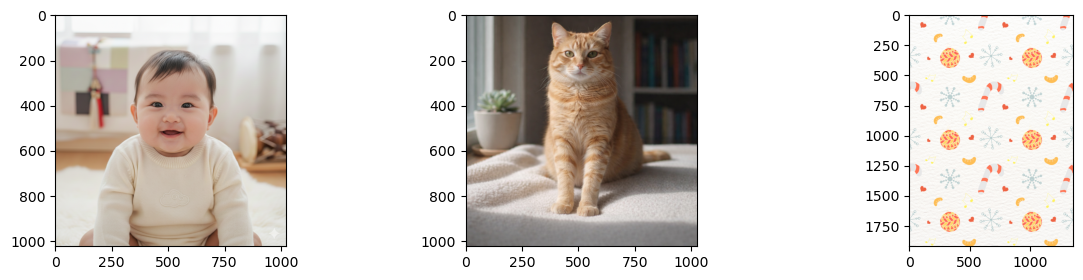

In [21]:
home_dir = os.getenv('HOME')
human_img_path = os.path.join(home_dir, "work/human_segmentation/images/human.png")
cat_img_path = os.path.join(home_dir, "work/human_segmentation/images/cat.png")  # 고양이 이미지를 준비해주세요
background_img_path = os.path.join(home_dir, "work/human_segmentation/images/background.png")  # 사막 배경 이미지를 준비해주세요

human_img = cv2.imread(human_img_path)
cat_img = cv2.imread(cat_img_path)
background_img = cv2.imread(background_img_path)

human_img = cv2.cvtColor(human_img, cv2.COLOR_BGR2RGB)
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
background_img = cv2.cvtColor(background_img, cv2.COLOR_BGR2RGB)

print(f"원본 사람 이미지 크기: {human_img.shape}")
print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"원본 배경 이미지 크기: {background_img.shape}")

plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.imshow(human_img)

plt.subplot(1, 3, 2)
plt.imshow(cat_img)

plt.subplot(1, 3, 3)
plt.imshow(background_img)

plt.show()

In [22]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [23]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (1024, 1024)


In [24]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [ 0  8 16]


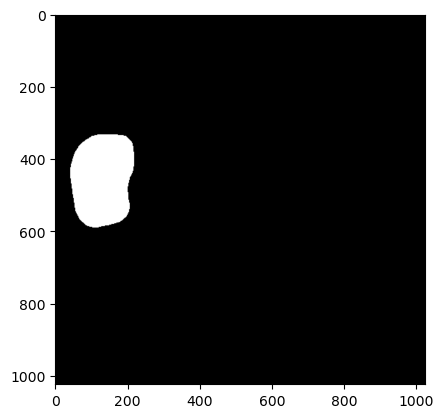

In [25]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

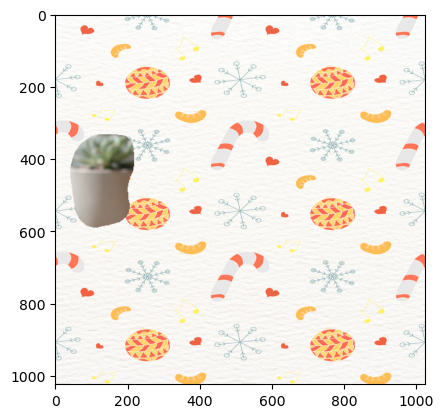

In [26]:
# 배경을 고양이 이미지 크기에 맞춤
background_img_resized = cv2.resize(background_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, background_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()